# Regressione Probabilistica tramite Processi Gaussiani (GPR)

In questa fase del progetto, l'obiettivo è modellare il **comportamento nominale** del motore aeronautico per definire un riferimento di "salute" della flotta. 
E' stata utilizzata la **Regressione tramite Processi Gaussiani (GPR)** per stimare la coppia target ($Trq_{target}$) in base alle condizioni operative.

Il valore aggiunto di questo approccio è la capacità di fornire non solo una stima puntuale, ma una **distribuzione di probabilità** che permette di calcolare il **Torque Margin** e la relativa incertezza.

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

current_dir = Path.cwd()
while not (current_dir / "src").exists() and current_dir != current_dir.parent:
    current_dir = current_dir.parent
SRC_DIR = current_dir / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataset import load_dataset
from regression.GPR.gpr_model import GPRModel
from regression.GPR.gpr_sampling import lhs_nearest_sampling
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target

plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [2]:
ROOT_DIR = Path(os.getcwd()).parents[3]
SRC_PATH = ROOT_DIR / "src"
DATA_PATH = ROOT_DIR / "data" / "processed"
OUTPUT_PATH = ROOT_DIR / "output" / "GPR" / "model_target"
OUTPUT_PATH_PREDICT = ROOT_DIR / "output" / "GPR" / "model_target" /"pred_margin_test.csv"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
OUTPUT_CSV = OUTPUT_PATH / "test_with_features_enriched.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model_5000.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
# Aggiunta ROOT_DIR al path per permettere a joblib di trovare i moduli custom
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))


In [3]:
FEATURES=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TARGET_NAME = 'trq_target'

In [7]:
train_df=load_dataset(TRAIN_PATH_SPLIT)
test_df=load_dataset(TEST_PATH_SPLIT)

In [8]:
gpr_model = GPRModel(random_state=42)

# 2. Controllo esistenza modelli
if MODEL_FILE.exists() and SCALER_FILE.exists():
    print("Modello pre-addestrato trovato! Caricamento in corso...")
    try:
        gpr_model = joblib.load(MODEL_FILE)
        scaler = joblib.load(SCALER_FILE)
        print("SUCCESSO: Modello e Scaler caricati correttamente.")
        addestramento_necessario = False
    except Exception as e:
        print(f"Errore nel caricamento dei file: {e}")
        addestramento_necessario = True
else:
    print("Modello non trovato o incompleto. Avvio procedura di addestramento...")
    addestramento_necessario = True

# 3. Addestramento (solo se necessario)
if addestramento_necessario:
    # Campionamento LHS e Normalizzazione (5000 campioni per la massima precisione)
    X_train_scaled, y_train, scaler = lhs_nearest_sampling(
        train_df, FEATURES, TARGET_NAME, n_samples=5000
    )

    # Fit del Modello GPR
    print("Addestramento GPR in corso")
    gpr_model.fit(X_train_scaled, y_train)

    # Salvataggio fisico
    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
    try:
        joblib.dump(gpr_model, MODEL_FILE)
        joblib.dump(scaler, SCALER_FILE)
        print(f"SUCCESSO: Modello salvato in -> {MODEL_FILE}")
        print(f"SUCCESSO: Scaler salvato in -> {SCALER_FILE}")
    except Exception as e:
        print(f"ERRORE DURANTE IL SALVATAGGIO: {e}")

Modello pre-addestrato trovato! Caricamento in corso...
SUCCESSO: Modello e Scaler caricati correttamente.


In [9]:
test_X=scaler.transform(test_df[FEATURES])
test_y=test_df[TARGET_NAME]

In [17]:
gpr_model.evaluate(test_X,test_y)

{'rmse': 0.034370512043997305,
 'mae': 0.012882274736953034,
 'r2': 0.9999941618705315}

TARGET

In [20]:
id =3
test_row = test_X[id:id+1]
feat = "trq_measured"
j = FEATURES.index(feat)   # posizione della feature
trq_measured_test = test_X[id, j]
test_y_true = float(test_y[id])
mu,std = gpr_model.model.predict(test_row,return_std=True)
mu_target = float(mu[0])
std_target=float(std[0])
print(std_target)


0.05772838763283422


MARGIN

Coppia Misurata (Sensore): 77.40
Coppia Target (Predetta): 71.08
Torque Margin VERO: 8.78%
Torque Margin PREDETTO: 8.90%
Deviazione Std del Margin: 0.0873

0.41605195789422983
1.0000000050001


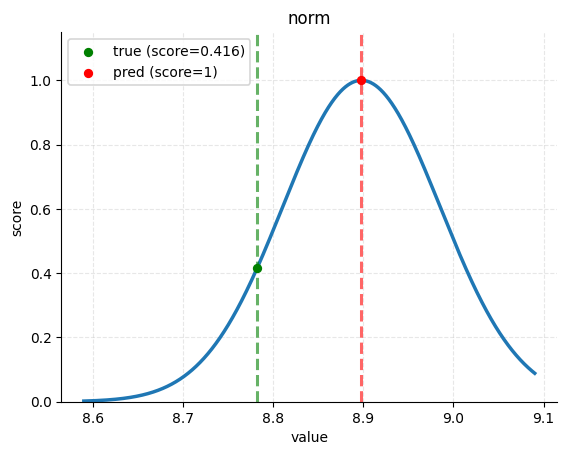

{'pdf_type': 'norm',
 'true_target': 8.78246545044803,
 'prediction': 8.898062362692771,
 'score_true': 0.41605195789422983,
 'score_pred': 1.0000000050001,
 'x_range': (8.5902639065704, 9.0902639065704)}

In [15]:
trq_measured_real = float(test_df.iloc[id]['trq_measured'])
trq_margin_true = 100 * (trq_measured_real / test_y_true - 1)
trq_margin_predetto = 100 * (trq_measured_real / mu_target - 1)

# 3. propagazione dell'incertezza con il Metodo Delta 
std_margin = np.abs(-100 * trq_measured_real / (mu_target**2)) * std_target

print(f"Coppia Misurata (Sensore): {trq_measured_real:.2f}")
print(f"Coppia Target (Predetta): {mu_target:.2f}")
print(f"Torque Margin VERO: {trq_margin_true:.2f}%")
print(f"Torque Margin PREDETTO: {trq_margin_predetto:.2f}%")
print(f"Deviazione Std del Margin: {std_margin:.4f}\n")

pdf_args = {"loc": trq_margin_predetto, "scale": std_margin}

plot_pdf_with_true_target(
    "norm",
    pdf_args=pdf_args,
    true_target=trq_margin_true,
    y_pred=trq_margin_predetto
)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 0) dati "veri" e input singolo
trq_measured_real = float(test_df.iloc[id]["trq_measured"])
test_y_true = float(test_y_true)  # assicurati sia float

# 1) campioni dal GP nel punto (coppia target)
n_draws = 1000
y_s = gpr_model.model.sample_y(test_row, n_samples=n_draws, random_state=0).ravel()

# 2) mu e std predittivi del GP nello stesso punto (coppia target)
mu_target, std_target = gpr_model.model.predict(test_row, return_std=True)
mu_target = float(np.ravel(mu_target)[0])  # sicurezza shape
std_target = float(np.ravel(std_target)[0])

# 3) trasformazione dei campioni -> torque margin (Monte Carlo)
eps = 1e-12
y_s_safe = np.clip(y_s, eps, None)  # evita divisioni per 0 / valori negativi
trq_margin_samples = 100.0 * (trq_measured_real / y_s_safe - 1.0)

# 4) torque margin vero e predetto (da mu_target)
trq_margin_true = 100.0 * (trq_measured_real / test_y_true - 1.0)
trq_margin_predetto = 100.0 * (trq_measured_real / mu_target - 1.0)

# 5) propagazione incertezza con Metodo Delta (sigma del margin)
std_margin = abs(-100.0 * trq_measured_real / (mu_target**2 + eps)) * std_target

print(f"Coppia Misurata (Sensore): {trq_measured_real:.2f}")
print(f"Coppia Target (Vera):      {test_y_true:.2f}")
print(f"Coppia Target (Predetta):  {mu_target:.2f} ± {std_target:.4f}")
print(f"Torque Margin VERO:        {trq_margin_true:.2f}%")
print(f"Torque Margin PREDETTO:    {trq_margin_predetto:.2f}% ± {std_margin:.4f}\n")

# 6) PDF normale sul margin (mu=margin_predetto, sigma=std_margin)
sigma = max(std_margin, 1e-12)
dist = stats.norm(loc=trq_margin_predetto, scale=sigma)

# griglia x (meglio centrata sul margin)
xx = np.linspace(trq_margin_predetto - 4*sigma, trq_margin_predetto + 4*sigma, 500)

# 7) plot: samples (margin) + pdf + true/pred
plt.figure(figsize=(8, 5))

plt.hist(trq_margin_samples, bins=30, density=True, alpha=0.35, label="Samples margin (MC da sample_y)")
plt.plot(xx, dist.pdf(xx), lw=2.5, label="Normal PDF margin (Delta method)")

plt.axvline(trq_margin_predetto, linestyle="--", label="margin predetto (mu)")
plt.axvline(trq_margin_true, color="red", linestyle="--", label="margin vero")

plt.xlabel("Torque Margin (%)")
plt.ylabel("density")
plt.title("GPR: distribuzione predittiva del Torque Margin (singolo campione)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8) args per salvare la pdf del margin
pdf_args = {"loc": trq_margin_predetto, "scale": std_margin}

IndexError: single positional indexer is out-of-bounds

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

idx = 98
flight_id = test_df.iloc[idx]['id'] if 'id' in test_df.columns else idx
test_row = test_X[idx:idx+1]

# B. Dati non scalati per la Matematica 
trq_measured_real = float(test_df.iloc[idx]['trq_measured'])

# Generazione campioni dal modello GPR
y_trq_samples = gpr_model.sample_y(test_row, n_sample=5000).flatten()

# trasfomrazione fisica del margin
margin_samples = 100 * (trq_measured_real / y_trq_samples - 1)

# 5. Calcolo Statistiche Empiriche 
mu_mc = np.mean(margin_samples)
var_mc = np.var(margin_samples)
std_mc = np.std(margin_samples)
ci_lower = np.percentile(margin_samples, 2.5)
ci_upper = np.percentile(margin_samples, 97.5)

# 6. Grafico 
plt.figure(figsize=(10, 6))
xmin = np.min(margin_samples)
xmax = np.max(margin_samples)
x_range = np.linspace(xmin, xmax, 1000)
plt.hist(margin_samples, bins=60, density=True, alpha=0.35, color='#1f77b4', 
         edgecolor='white', label='Istogramma (Monte Carlo)')
y_pdf = stats.norm.pdf(x_range, mu_mc, std_mc)
plt.plot(x_range, y_pdf, color='#0d3a66', lw=2.5, label='Curva Gaussiana')
plt.axvline(mu_mc, color='red', linestyle='--', lw=2, label=f'Media: {mu_mc:.2f}%')
plt.fill_between(x_range, y_pdf, 
                 where=(x_range >= ci_lower) & (x_range <= ci_upper), 
                 color='#1f77b4', alpha=0.2, label='Confidenza 95%')
plt.title(f'Analisi Probabilistica Monte Carlo - Volo ID: {int(flight_id)}')
plt.xlabel('Torque Margin (%)')
plt.ylabel('Densità')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Tabella Statistica Riassuntiva
stats_data = {
    "Parametro": [
        "ID Volo", 
        "Media Margine (μ)", 
        "Varianza (σ²)", 
        "Deviazione Standard (σ)", 
        "Intervallo Confidenza (95%)"
    ],
    "Valore": [
        int(flight_id), 
        f"{mu_mc:.4f}", 
        f"{var_mc:.6f}", 
        f"{std_mc:.4f}", 
        f"[{ci_lower:.2f} , {ci_upper:.2f}]"
    ]
}

display(pd.DataFrame(stats_data))

In [9]:
predict_margin=gpr_model.predict_mu_std_all(test_df,test_df["trq_margin"],FEATURES=FEATURES,keep_cols=["mgt","ias","oat","np_ng_ratio","pa","faulty"],scaler=scaler)
predict_margin.head()

,id,trq_target_pred,trq_margin_pred,trq_margin_std,trq_margin_true,mgt,ias,oat,np_ng_ratio,pa,faulty
0,0,46.271792,12.595596,0.145244,12.592889,560.9,38.0000,24.75,1.105310,134.1120,0
1,1,71.368120,2.426686,0.082345,2.416570,619.8,111.6250,17.25,1.060725,456.5904,0
2,2,81.994205,-7.066603,0.065477,-7.046420,655.8,111.5625,18.25,1.040232,284.3784,1
3,3,65.471641,7.069257,0.094400,6.950626,571.9,101.7500,7.75,1.083732,340.7664,0
4,4,78.849571,-0.823810,0.072258,-0.905030,607.9,20.0625,5.50,0.944311,369.4176,0


In [10]:
predict_margin.to_csv(OUTPUT_PATH_PREDICT)